In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

dataset = "rte"
seed = 2026
selected_dp_percent = [i for i in range(1, 101)]
iteration = 500


def plot_data_selection(seed, dataset, train_data, g, iteration=500):
    """Plot 9-subplot data-selection figure for one (dataset, train_data) setting.

    Looks up the following variables from g (caller's globals()):
      - seed{seed}_{dataset}_{train_data}_inv_lam1e_6
      - seed{seed}_{dataset}_{train_data}_r{R}_eigen1e_2_inv1e_6     (R in ranks)
      - seed{seed}_{dataset}_{train_data}_r{R}_eigen1e_2_eigen1e_2   (R in ranks)
      - seed{seed}_{dataset}_{train_data}_A_BASE
      - seed{seed}_{dataset}_{train_data}_inv_early_stop
      - seed{seed}_{dataset}_{train_data}_topr_early_stop
      - selected_dp_percent  (shared)
    """
    selected_dp_percent = g["selected_dp_percent"]
    inv             = g[f"seed{seed}_{dataset}_{train_data}_inv_lam1e_6"]
    A_BASE          = g[f"seed{seed}_{dataset}_{train_data}_A_BASE"]
    inv_early_stop  = g[f"seed{seed}_{dataset}_{train_data}_inv_early_stop"]
    topr_early_stop = g[f"seed{seed}_{dataset}_{train_data}_topr_early_stop"]

    ranks = [1, 5, 10, 15, 20, 25, 30]
    eigen_data_1 = [(g[f"seed{seed}_{dataset}_{train_data}_r{r}_eigen1e_2_eigen1e_2"], f"rank {r}%") for r in ranks]
    eigen_data_2 = [(g[f"seed{seed}_{dataset}_{train_data}_r{r}_eigen1e_2_inv1e_6"],   f"rank {r}%") for r in ranks]
    diff_data    = [(np.array(d1) - np.array(d2), lab)
                    for (d1, lab), (d2, _) in zip(eigen_data_1, eigen_data_2)]

    num_dp = train_data
    ZOOM_PCT = 20
    ZOOM_N = ZOOM_PCT

    fig, axes = plt.subplots(3, 3, figsize=(30, 28))
    axes = axes.flatten()

    inv_color = "red"
    eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

    # ===== Subplot (1,1): Eigen mode (shapley + prediction) - 1~ZOOM_PCT% =====
    ax1 = axes[0]
    plot_percent_10 = selected_dp_percent[:ZOOM_N]
    ax1.plot(plot_percent_10, inv[:ZOOM_N], color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=10, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_1):
        ax1.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=10, label=label, alpha=0.85)

    all_data_10_eigen = [inv[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_1]
    y_min_10 = min(min(d) for d in all_data_10_eigen)
    y_max_10 = max(max(d) for d in all_data_10_eigen)
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ylim_10_min = y_min_10 - y_margin_10
    ylim_10_max = y_max_10 + y_margin_10

    ax1.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax1.set_ylabel("Accuracy", fontsize=20)
    ax1.set_title(f"Eigen Shapley + Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax1.legend(fontsize=20, loc="best")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax1.set_ylim(ylim_10_min, ylim_10_max)
    ax1.tick_params(axis="both", labelsize=18)

    # ===== Subplot (1,2): Eigen shapley + INV prediction - 1~ZOOM_PCT% =====
    ax2 = axes[1]
    ax2.plot(plot_percent_10, inv[:ZOOM_N], color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=10, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_2):
        ax2.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=10, label=label, alpha=0.85)

    all_data_10_inv = [inv[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_2]
    y_min_10_inv = min(min(d) for d in all_data_10_inv)
    y_max_10_inv = max(max(d) for d in all_data_10_inv)
    ylim_10_min = min(ylim_10_min, y_min_10_inv - (y_max_10_inv - y_min_10_inv) * 0.1)
    ylim_10_max = max(ylim_10_max, y_max_10_inv + (y_max_10_inv - y_min_10_inv) * 0.1)

    ax2.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax2.set_ylabel("Accuracy", fontsize=20)
    ax2.set_title(f"Eigen Shapley + INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax2.legend(fontsize=20, loc="best")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax2.set_ylim(ylim_10_min, ylim_10_max)
    ax2.tick_params(axis="both", labelsize=18)

    ax1.set_ylim(ylim_10_min, ylim_10_max)

    # ===== Subplot (1,3): Difference (Eigen - INV) - 1~100% =====
    ax3 = axes[2]
    for i, (data, label) in enumerate(diff_data):
        ax3.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="d", markersize=6, label=label, alpha=0.85)

    all_diff_data = [d[0] for d in diff_data]
    y_min_diff = min(min(d) for d in all_diff_data)
    y_max_diff = max(max(d) for d in all_diff_data)
    y_margin_diff = max(abs(y_min_diff), abs(y_max_diff)) * 0.1
    ylim_diff_min = y_min_diff - y_margin_diff
    ylim_diff_max = y_max_diff + y_margin_diff

    ax3.axhline(y=0, color="black", linestyle="--", linewidth=1.5, alpha=0.5)
    ax3.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax3.set_ylabel("Accuracy Difference", fontsize=20)
    ax3.set_title(f"Difference (Eigen Pred - INV Pred) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax3.legend(fontsize=20, loc="best")
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, 101)
    ax3.set_ylim(ylim_diff_min, ylim_diff_max)
    ax3.tick_params(axis="both", labelsize=18)

    # ===== Subplot (2,1): Eigen mode (shapley + prediction) - 1~100% =====
    ax4 = axes[3]
    ax4.plot(selected_dp_percent, inv, color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=6, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_1):
        ax4.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=6, label=label, alpha=0.85)

    all_data_100_eigen = [inv] + [d[0] for d in eigen_data_1]
    y_min_100 = min(min(d) for d in all_data_100_eigen)
    y_max_100 = max(max(d) for d in all_data_100_eigen)
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ylim_100_min = y_min_100 - y_margin_100
    ylim_100_max = y_max_100 + y_margin_100

    ax4.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax4.set_ylabel("Accuracy", fontsize=20)
    ax4.set_title(f"Eigen Shapley + Eigen Pred (1-100%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax4.legend(fontsize=20, loc="best")
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(0, 101)
    ax4.set_ylim(ylim_100_min, ylim_100_max)
    ax4.tick_params(axis="both", labelsize=18)

    # ===== Subplot (2,2): Eigen shapley + INV prediction - 1~100% =====
    ax5 = axes[4]
    ax5.plot(selected_dp_percent, inv, color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=6, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_2):
        ax5.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=6, label=label, alpha=0.85)

    all_data_100_inv = [inv] + [d[0] for d in eigen_data_2]
    y_min_100_inv = min(min(d) for d in all_data_100_inv)
    y_max_100_inv = max(max(d) for d in all_data_100_inv)
    ylim_100_min = min(ylim_100_min, y_min_100_inv - (y_max_100_inv - y_min_100_inv) * 0.1)
    ylim_100_max = max(ylim_100_max, y_max_100_inv + (y_max_100_inv - y_min_100_inv) * 0.1)

    ax5.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax5.set_ylabel("Accuracy", fontsize=20)
    ax5.set_title(f"Eigen Shapley + INV Pred (1-100%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax5.legend(fontsize=20, loc="best")
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim(0, 101)
    ax5.set_ylim(ylim_100_min, ylim_100_max)
    ax5.tick_params(axis="both", labelsize=18)

    ax4.set_ylim(ylim_100_min, ylim_100_max)

    # ===== Subplot (2,3): Early Stop Ratio =====
    ax6 = axes[5]
    method_names = ["INV"] + [f"rank {r}%" for r in ranks]
    method_values = [inv_early_stop[0]] + list(topr_early_stop)
    bar_colors = [inv_color] + list(eigen_colors)
    x_pos = np.arange(len(method_names))
    bars = ax6.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor="black", linewidth=1.2)
    for bar, value in zip(bars, method_values):
        ax6.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                 f"{value:.2f}", ha="center", va="bottom", fontsize=20, fontweight="bold")
    ax6.set_xlabel("Method", fontsize=20)
    ax6.set_ylabel("Early Stop Ratio (%)", fontsize=20)
    ax6.set_title(f"Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(method_names, fontsize=20)
    ax6.grid(True, alpha=0.3, axis="y")
    ax6.tick_params(axis="y", labelsize=18)

    # ===== Subplot (3,1): ER for Eigen Pred - 1~ZOOM_PCT% =====
    ax7 = axes[6]
    inv_zoom_arr = np.array(inv[:ZOOM_N])

    er_data_eigen = []
    for i, (data, label) in enumerate(eigen_data_1):
        ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
        er_data_eigen.append((ers, f"{label} ({np.mean(ers):.3f}±{np.std(ers):.3f})"))

    for i, (ers, label) in enumerate(er_data_eigen):
        ax7.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=10, label=label, alpha=0.85)
    ax7.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, label="y=1 (baseline)")
    ax7.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax7.set_ylabel("Excess Retention (ER)", fontsize=20)
    ax7.set_title(f"ER: Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax7.legend(fontsize=20, loc="best")
    ax7.grid(True, alpha=0.3)
    ax7.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax7.tick_params(axis="both", labelsize=18)

    # ===== Subplot (3,2): ER for INV Pred - 1~ZOOM_PCT% =====
    ax8 = axes[7]
    er_data_inv = []
    for i, (data, label) in enumerate(eigen_data_2):
        ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
        er_data_inv.append((ers, f"{label} ({np.mean(ers):.3f}±{np.std(ers):.3f})"))

    for i, (ers, label) in enumerate(er_data_inv):
        ax8.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=10, label=label, alpha=0.85)
    ax8.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, label="y=1 (baseline)")
    ax8.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax8.set_ylabel("Excess Retention (ER)", fontsize=20)
    ax8.set_title(f"ER: INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax8.legend(fontsize=20, loc="best")
    ax8.grid(True, alpha=0.3)
    ax8.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax8.tick_params(axis="both", labelsize=18)

    # ===== Subplot (3,3): Turn off =====
    axes[8].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:

# ===== Configuration =====
num_dp = 1000
# =========================

seed2026_rte_1000_A_BASE = 

seed2026_rte_1000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_rte_1000_r1_eigen1e_2_inv1e_6  = 
seed2026_rte_1000_r5_eigen1e_2_inv1e_6  = 
seed2026_rte_1000_r10_eigen1e_2_inv1e_6 = 
seed2026_rte_1000_r15_eigen1e_2_inv1e_6 = 
seed2026_rte_1000_r20_eigen1e_2_inv1e_6 = 
seed2026_rte_1000_r25_eigen1e_2_inv1e_6 = 
seed2026_rte_1000_r30_eigen1e_2_inv1e_6 = 

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_rte_1000_r1_eigen1e_2_eigen1e_2  = 
seed2026_rte_1000_r5_eigen1e_2_eigen1e_2  = 
seed2026_rte_1000_r10_eigen1e_2_eigen1e_2 = 
seed2026_rte_1000_r15_eigen1e_2_eigen1e_2 = 
seed2026_rte_1000_r20_eigen1e_2_eigen1e_2 = 
seed2026_rte_1000_r25_eigen1e_2_eigen1e_2 = 
seed2026_rte_1000_r30_eigen1e_2_eigen1e_2 = 

seed2026_rte_1000_inv_early_stop  = []
seed2026_rte_1000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
# =========================

seed2026_rte_2000_A_BASE = 

seed2026_rte_2000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_rte_2000_r1_eigen1e_2_inv1e_6  = 
seed2026_rte_2000_r5_eigen1e_2_inv1e_6  = 
seed2026_rte_2000_r10_eigen1e_2_inv1e_6 = 
seed2026_rte_2000_r15_eigen1e_2_inv1e_6 = 
seed2026_rte_2000_r20_eigen1e_2_inv1e_6 = 
seed2026_rte_2000_r25_eigen1e_2_inv1e_6 = 
seed2026_rte_2000_r30_eigen1e_2_inv1e_6 = 

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_rte_2000_r1_eigen1e_2_eigen1e_2  = 
seed2026_rte_2000_r5_eigen1e_2_eigen1e_2  = 
seed2026_rte_2000_r10_eigen1e_2_eigen1e_2 = 
seed2026_rte_2000_r15_eigen1e_2_eigen1e_2 = 
seed2026_rte_2000_r20_eigen1e_2_eigen1e_2 = 
seed2026_rte_2000_r25_eigen1e_2_eigen1e_2 = 
seed2026_rte_2000_r30_eigen1e_2_eigen1e_2 = 

seed2026_rte_2000_inv_early_stop  = []
seed2026_rte_2000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


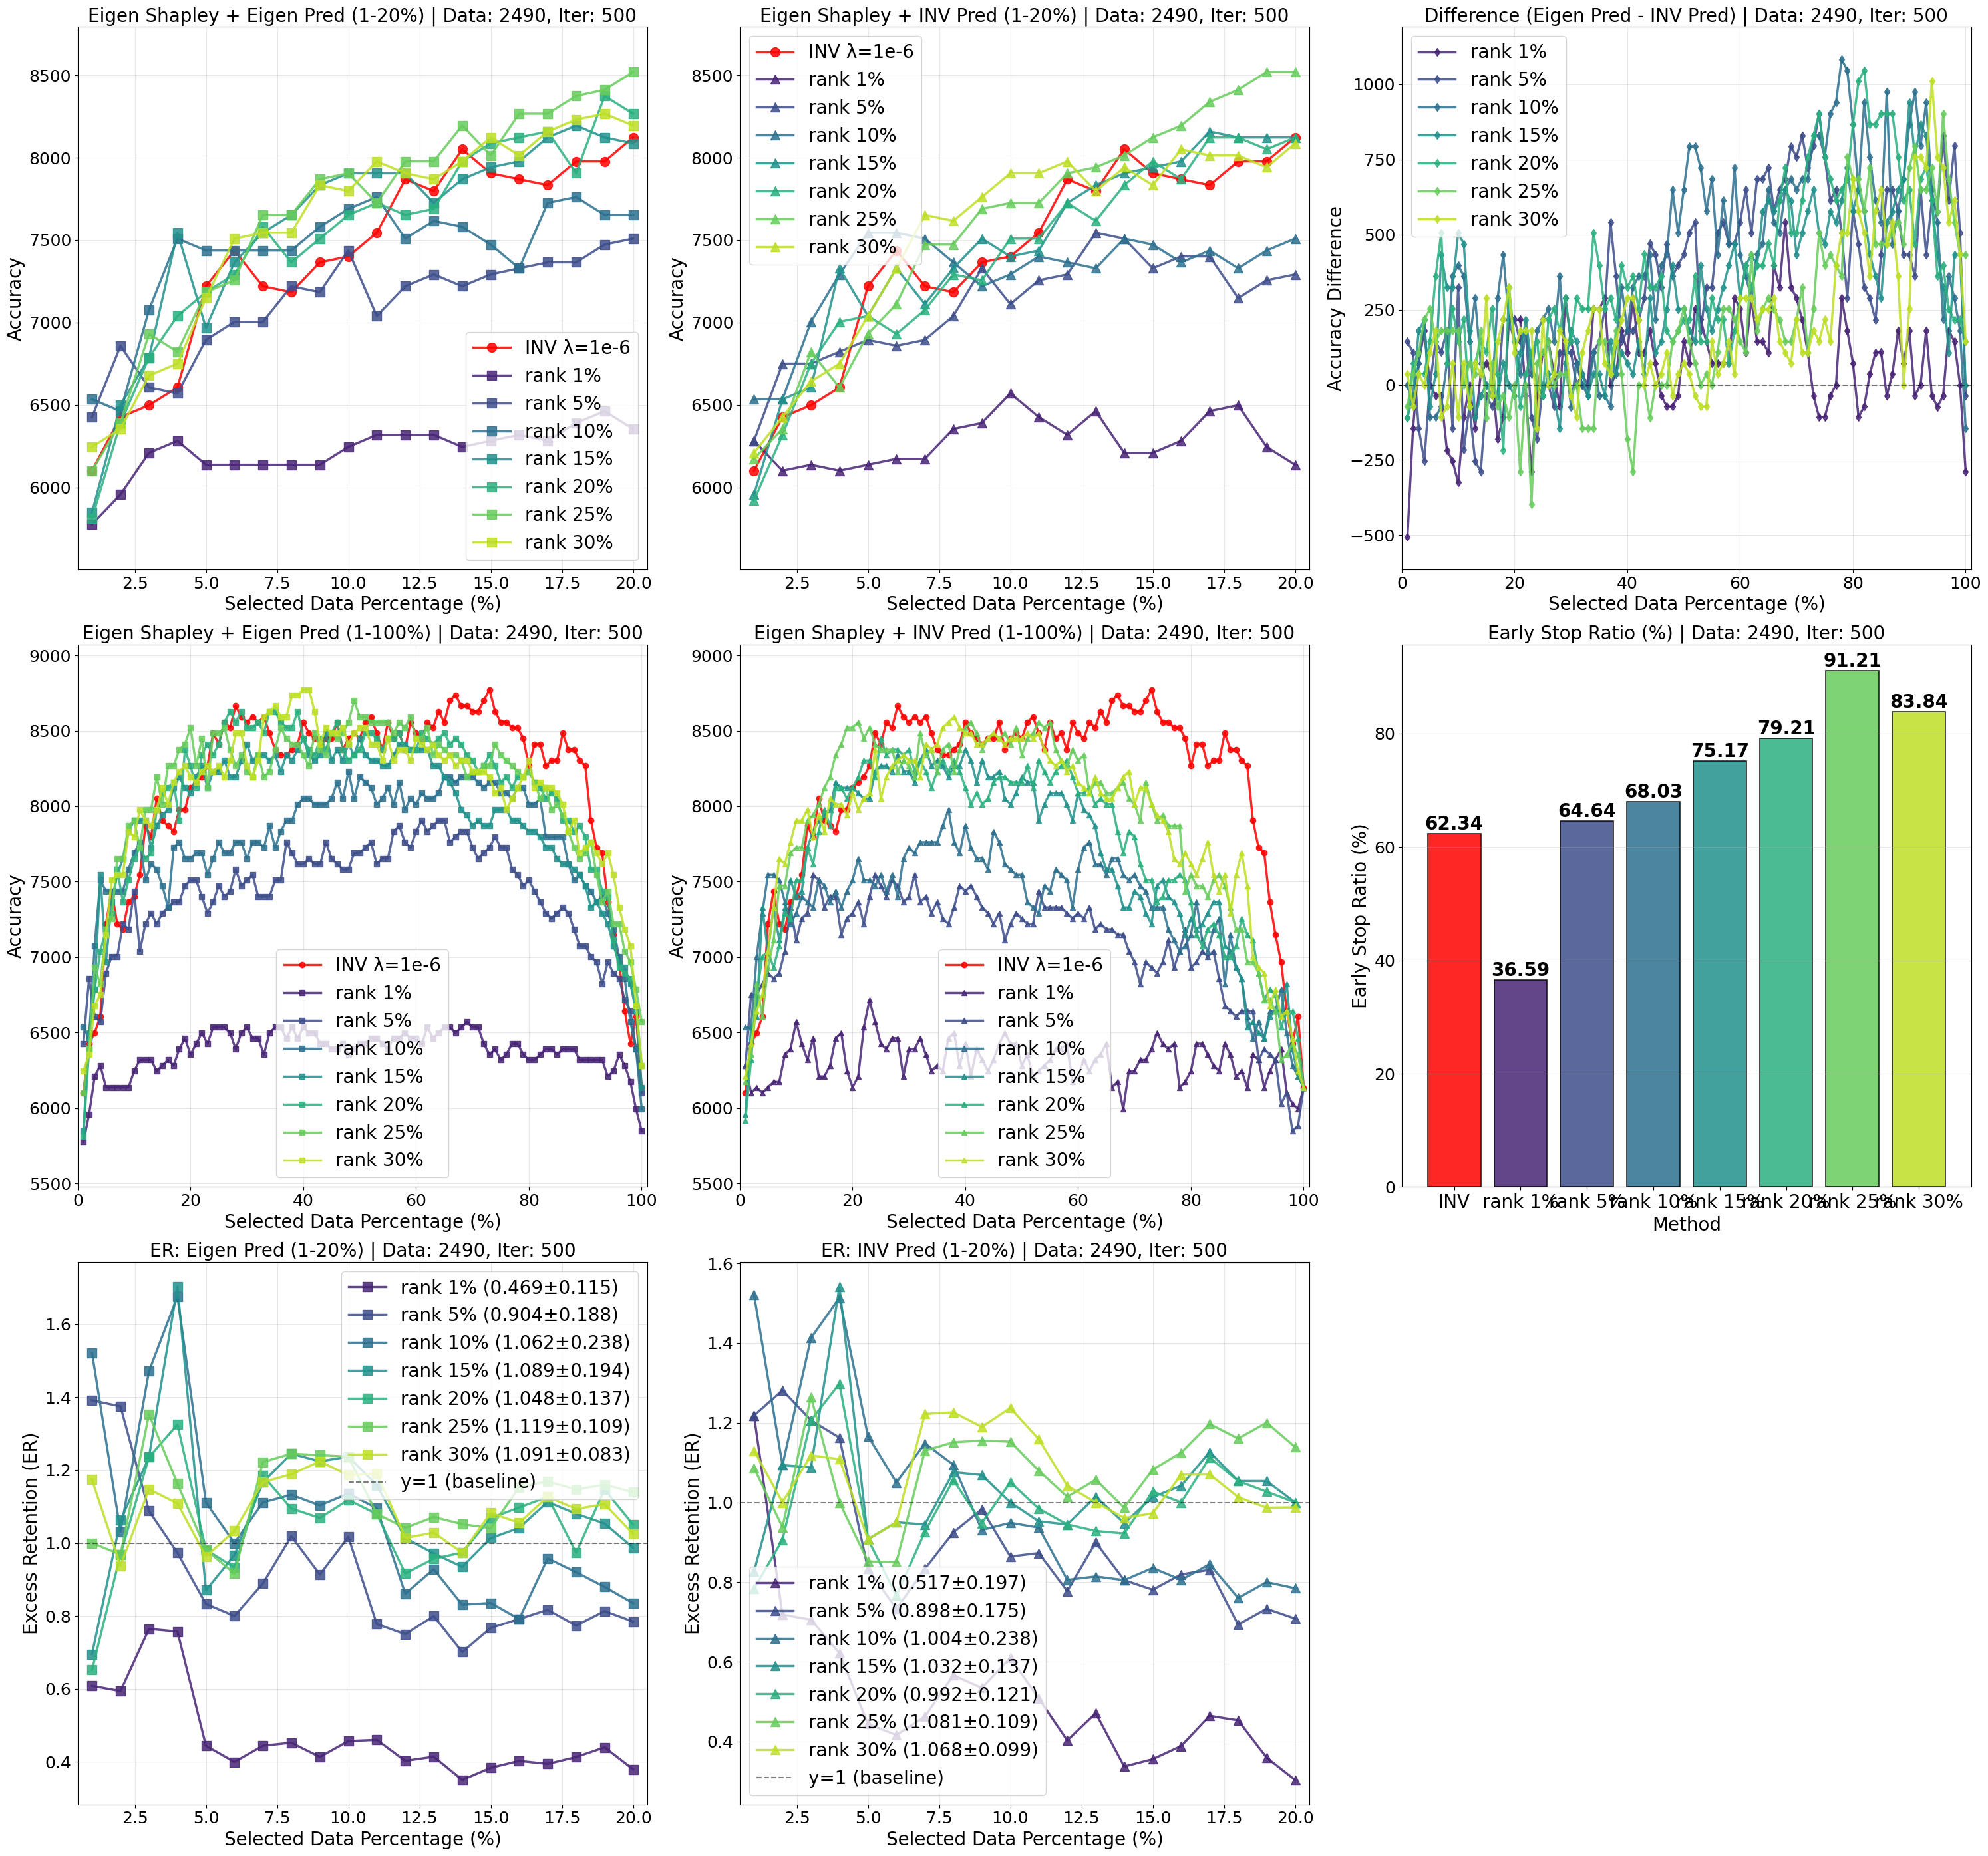

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2490
# =========================

seed2026_rte_2490_A_BASE = 5271

seed2026_rte_2490_inv_lam1e_6           = [6101, 6426, 6498, 6606, 7220, 7437, 7220, 7184, 7365, 7401, 7545, 7870, 7798, 8051, 7906, 7870, 7834, 7978, 7978, 8123, 8159, 8195, 8267, 8484, 8412, 8556, 8520, 8664, 8592, 8556, 8592, 8556, 8592, 8484, 8375, 8339, 8339, 8375, 8412, 8556, 8484, 8448, 8412, 8448, 8448, 8556, 8375, 8448, 8484, 8448, 8556, 8592, 8484, 8375, 8556, 8448, 8484, 8375, 8556, 8484, 8448, 8556, 8520, 8628, 8556, 8700, 8736, 8664, 8664, 8628, 8628, 8700, 8773, 8628, 8556, 8556, 8520, 8520, 8448, 8267, 8412, 8412, 8267, 8303, 8303, 8484, 8375, 8375, 8303, 8267, 7906, 7726, 7690, 7365, 7148, 6968, 6643, 6426, 6606, 6137]
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2026_rte_2490_r1_eigen1e_2_inv1e_6  = [6282, 6101, 6137, 6101, 6137, 6173, 6173, 6354, 6390, 6570, 6426, 6318, 6462, 6209, 6209, 6282, 6462, 6498, 6245, 6137, 6209, 6534, 6715, 6570, 6426, 6390, 6462, 6462, 6209, 6390, 6390, 6462, 6354, 6245, 6282, 6245, 6462, 6498, 6282, 6426, 6209, 6390, 6318, 6245, 6318, 6426, 6498, 6426, 6426, 6282, 6354, 6209, 6245, 6282, 6318, 6390, 6390, 6426, 6173, 6209, 6318, 6245, 6318, 6354, 6426, 6137, 6173, 5993, 6245, 6245, 6318, 6318, 6390, 6498, 6426, 6390, 6426, 6137, 6173, 6245, 6426, 6426, 6354, 6282, 6245, 6426, 6354, 6209, 6245, 6137, 6354, 6318, 6137, 6245, 6318, 6390, 6101, 6029, 5993, 6137]
seed2026_rte_2490_r5_eigen1e_2_inv1e_6  = [6282, 6751, 6751, 6823, 6895, 6859, 6895, 7040, 7329, 7112, 7256, 7292, 7545, 7509, 7329, 7401, 7401, 7148, 7256, 7292, 7365, 7220, 7401, 7545, 7473, 7401, 7509, 7473, 7365, 7401, 7545, 7365, 7401, 7292, 7365, 7256, 7220, 7329, 7473, 7437, 7473, 7401, 7329, 7292, 7220, 7292, 7112, 7220, 7292, 7256, 7220, 7220, 7437, 7329, 7329, 7329, 7329, 7292, 7256, 7292, 7256, 7329, 7184, 7220, 7184, 7184, 7148, 7148, 7040, 6968, 6823, 6968, 6931, 6895, 6968, 7112, 6931, 7040, 7184, 6931, 6968, 7040, 7004, 7040, 6859, 6679, 6643, 6606, 6643, 6643, 6643, 6318, 6390, 6354, 6318, 6029, 6101, 5848, 5884, 6137]
seed2026_rte_2490_r10_eigen1e_2_inv1e_6 = [6534, 6534, 7004, 7292, 7545, 7545, 7509, 7365, 7220, 7292, 7401, 7365, 7329, 7509, 7473, 7365, 7437, 7329, 7437, 7509, 7653, 7509, 7509, 7473, 7545, 7437, 7545, 7401, 7653, 7726, 7690, 7762, 7762, 7762, 7762, 7870, 7978, 7762, 7690, 7870, 7726, 7653, 7653, 7581, 7834, 7762, 7617, 7581, 7545, 7545, 7365, 7329, 7292, 7473, 7437, 7581, 7545, 7509, 7329, 7581, 7726, 7762, 7617, 7617, 7545, 7653, 7653, 7545, 7509, 7545, 7473, 7437, 7329, 7329, 7329, 7184, 7112, 7040, 7076, 7148, 7365, 7112, 7040, 7184, 7256, 6823, 7148, 6931, 6859, 6606, 6462, 6570, 6462, 6643, 6643, 6787, 6498, 6282, 6209, 6137]
seed2026_rte_2490_r15_eigen1e_2_inv1e_6 = [5957, 6534, 6606, 7329, 7040, 7329, 7112, 7329, 7509, 7401, 7437, 7726, 7834, 7906, 7942, 7978, 8159, 8123, 8123, 8123, 8087, 8051, 8051, 8231, 8267, 8267, 8231, 8339, 8231, 8231, 8159, 8303, 8375, 8267, 8303, 8267, 8195, 8267, 8267, 8375, 8303, 8159, 8303, 8195, 8195, 8231, 8051, 8014, 8087, 8195, 8159, 8159, 7906, 8014, 8087, 8087, 8087, 8014, 7906, 8087, 7978, 7942, 7870, 7690, 7581, 7581, 7473, 7329, 7329, 7437, 7401, 7292, 7220, 7473, 7509, 7401, 7365, 7292, 7148, 7256, 7184, 7220, 7292, 7365, 7365, 7076, 7040, 6931, 6859, 6534, 6570, 6498, 6462, 6606, 6643, 6643, 6823, 6390, 6209, 6137]
seed2026_rte_2490_r20_eigen1e_2_inv1e_6 = [5921, 6318, 6751, 7004, 7040, 6931, 7076, 7292, 7256, 7509, 7509, 7726, 7617, 7834, 7978, 7870, 8123, 8123, 8051, 8123, 8195, 8303, 8303, 8195, 8448, 8339, 8375, 8375, 8339, 8375, 8231, 8303, 8231, 8123, 8231, 8303, 8231, 8303, 8231, 8123, 8014, 8087, 8014, 8051, 8159, 8195, 8195, 8159, 8159, 8159, 8267, 8123, 8303, 8231, 8159, 8231, 8267, 8303, 8195, 8087, 8087, 8123, 8014, 8051, 8014, 8014, 7834, 7690, 7834, 7798, 7617, 7509, 7509, 7365, 7401, 7509, 7509, 7545, 7509, 7365, 7148, 7076, 7184, 7220, 7148, 7004, 7004, 7076, 7256, 7148, 7112, 6895, 6715, 6787, 6751, 6534, 6643, 6643, 6462, 6137]
seed2026_rte_2490_r25_eigen1e_2_inv1e_6 = [6173, 6354, 6823, 6606, 6931, 7112, 7473, 7473, 7690, 7726, 7726, 7906, 7942, 8014, 8123, 8195, 8339, 8412, 8520, 8520, 8556, 8448, 8520, 8412, 8375, 8375, 8375, 8231, 8303, 8267, 8195, 8484, 8339, 8375, 8231, 8375, 8412, 8231, 8375, 8520, 8556, 8484, 8375, 8448, 8484, 8448, 8484, 8412, 8520, 8339, 8448, 8484, 8556, 8520, 8556, 8375, 8303, 8267, 8375, 8303, 8339, 8087, 8159, 8159, 8087, 8087, 8123, 8159, 8051, 8014, 7906, 8159, 8014, 7906, 7942, 7870, 7870, 7870, 7437, 7545, 7473, 7473, 7401, 7509, 7545, 7473, 7329, 7184, 7184, 6968, 6968, 6895, 6715, 6715, 6643, 6318, 6354, 6426, 6354, 6137]
seed2026_rte_2490_r30_eigen1e_2_inv1e_6 = [6209, 6426, 6643, 6751, 7040, 7329, 7653, 7617, 7762, 7906, 7906, 7978, 7798, 7942, 7834, 8051, 8014, 8014, 7942, 8087, 7978, 8051, 8087, 8375, 8051, 8195, 8267, 8303, 8339, 8303, 8303, 8195, 8412, 8375, 8412, 8520, 8556, 8592, 8520, 8484, 8484, 8412, 8412, 8448, 8484, 8448, 8412, 8448, 8448, 8448, 8484, 8448, 8484, 8375, 8303, 8267, 8303, 8231, 8267, 8159, 8123, 8087, 8195, 8087, 8051, 8051, 8123, 8195, 8231, 8014, 8123, 8123, 8014, 7942, 7906, 7834, 7653, 7617, 7690, 7617, 7545, 7653, 7762, 7545, 7437, 7545, 7292, 7545, 7690, 7473, 7004, 6931, 6895, 6679, 6787, 6606, 6643, 6462, 6245, 6137]

# Predction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2026_rte_2490_r1_eigen1e_2_eigen1e_2  = [5776, 5957, 6209, 6282, 6137, 6137, 6137, 6137, 6137, 6245, 6318, 6318, 6318, 6245, 6282, 6318, 6282, 6390, 6462, 6354, 6426, 6498, 6426, 6534, 6534, 6534, 6498, 6390, 6498, 6534, 6462, 6462, 6354, 6498, 6534, 6534, 6462, 6534, 6462, 6534, 6498, 6498, 6426, 6426, 6390, 6390, 6426, 6354, 6390, 6426, 6426, 6462, 6462, 6426, 6390, 6462, 6462, 6498, 6462, 6462, 6426, 6534, 6462, 6498, 6534, 6534, 6498, 6534, 6570, 6534, 6534, 6426, 6354, 6390, 6318, 6354, 6426, 6426, 6354, 6318, 6318, 6354, 6390, 6390, 6354, 6390, 6390, 6390, 6318, 6318, 6318, 6318, 6318, 6209, 6245, 6354, 6282, 6173, 5993, 5848]
seed2026_rte_2490_r5_eigen1e_2_eigen1e_2  = [6426, 6859, 6606, 6570, 6895, 7004, 7004, 7220, 7184, 7437, 7040, 7220, 7292, 7220, 7292, 7329, 7365, 7365, 7473, 7509, 7509, 7401, 7292, 7365, 7473, 7401, 7437, 7581, 7473, 7509, 7545, 7401, 7401, 7401, 7509, 7509, 7762, 7690, 7617, 7617, 7653, 7617, 7617, 7762, 7653, 7617, 7581, 7581, 7690, 7690, 7726, 7762, 7617, 7653, 7653, 7834, 7870, 7762, 7726, 7834, 7906, 7834, 7870, 7906, 7906, 7762, 7798, 7834, 7834, 7726, 7653, 7690, 7726, 7798, 7726, 7726, 7581, 7545, 7473, 7509, 7437, 7365, 7292, 7256, 7292, 7329, 7292, 7184, 7076, 7076, 7004, 6968, 6823, 6968, 6895, 6859, 6715, 6643, 6390, 6101]
seed2026_rte_2490_r10_eigen1e_2_eigen1e_2 = [6534, 6462, 7076, 7509, 7437, 7437, 7437, 7437, 7581, 7690, 7762, 7509, 7617, 7581, 7473, 7329, 7726, 7762, 7653, 7653, 7690, 7690, 7545, 7653, 7762, 7690, 7690, 7762, 7762, 7653, 7762, 7762, 7726, 7870, 7726, 7834, 7906, 7906, 8014, 8051, 8051, 8014, 8014, 8014, 8051, 8159, 8051, 8231, 8051, 8195, 8159, 8123, 8014, 8051, 8123, 8014, 8159, 7978, 8051, 8014, 8087, 8051, 8051, 8087, 8195, 8195, 8159, 8195, 8195, 8195, 8159, 8123, 8159, 8159, 8087, 8087, 8051, 8123, 8123, 8014, 8014, 8051, 7798, 7798, 7798, 7798, 7617, 7509, 7545, 7473, 7437, 7365, 7401, 7292, 7184, 7004, 6859, 6570, 6390, 5993]
seed2026_rte_2490_r15_eigen1e_2_eigen1e_2 = [5848, 6498, 6787, 7545, 6968, 7365, 7545, 7653, 7834, 7906, 7906, 7906, 7726, 7870, 7942, 7978, 8123, 8195, 8123, 8087, 8195, 8267, 8123, 8231, 8231, 8303, 8195, 8195, 8303, 8412, 8303, 8339, 8339, 8303, 8339, 8231, 8339, 8303, 8375, 8448, 8339, 8303, 8339, 8484, 8303, 8375, 8303, 8412, 8339, 8448, 8339, 8303, 8303, 8267, 8267, 8339, 8412, 8412, 8375, 8375, 8375, 8375, 8267, 8267, 8195, 8159, 8087, 7978, 7942, 7870, 7906, 7870, 7870, 7978, 7978, 7978, 7906, 7906, 7870, 7834, 7834, 7798, 7726, 7726, 7653, 7617, 7617, 7581, 7545, 7473, 7329, 7365, 7292, 7220, 7076, 6968, 6931, 6823, 6643, 6137]
seed2026_rte_2490_r20_eigen1e_2_eigen1e_2 = [5812, 6390, 6787, 7040, 7184, 7292, 7581, 7365, 7509, 7653, 7726, 7653, 7690, 7978, 8087, 8123, 8159, 7906, 8375, 8267, 8123, 8339, 8412, 8339, 8412, 8556, 8628, 8556, 8628, 8520, 8520, 8556, 8484, 8628, 8628, 8556, 8520, 8520, 8628, 8448, 8375, 8339, 8448, 8375, 8484, 8556, 8375, 8303, 8339, 8375, 8484, 8484, 8448, 8375, 8448, 8448, 8484, 8375, 8375, 8375, 8484, 8448, 8412, 8448, 8484, 8412, 8448, 8412, 8339, 8303, 8231, 8267, 8339, 8267, 8159, 8195, 8123, 8195, 8195, 8231, 8159, 8123, 8051, 8087, 8051, 7906, 7906, 7834, 7870, 7798, 7581, 7581, 7437, 7401, 7112, 6931, 6895, 6859, 6679, 6282]
seed2026_rte_2490_r25_eigen1e_2_eigen1e_2 = [6101, 6390, 6931, 6823, 7184, 7256, 7653, 7653, 7870, 7906, 7726, 7978, 7978, 8195, 8014, 8267, 8267, 8375, 8412, 8520, 8267, 8448, 8123, 8484, 8484, 8520, 8375, 8267, 8339, 8231, 8195, 8339, 8195, 8231, 8375, 8520, 8448, 8412, 8412, 8339, 8267, 8484, 8375, 8339, 8484, 8448, 8484, 8556, 8700, 8592, 8592, 8556, 8556, 8556, 8556, 8484, 8556, 8520, 8592, 8448, 8448, 8520, 8339, 8412, 8375, 8339, 8339, 8303, 8195, 8231, 8231, 8267, 8267, 8412, 8339, 8303, 8267, 8231, 8195, 8231, 8159, 8051, 8123, 7978, 8014, 7942, 7834, 7726, 7653, 7690, 7762, 7545, 7365, 7437, 7220, 7220, 7040, 6968, 6787, 6570]
seed2026_rte_2490_r30_eigen1e_2_eigen1e_2 = [6245, 6354, 6679, 6751, 7148, 7509, 7545, 7545, 7834, 7798, 7978, 7906, 7870, 7978, 8123, 8014, 8159, 8231, 8267, 8195, 8159, 8231, 8267, 8231, 8267, 8195, 8303, 8484, 8484, 8267, 8195, 8303, 8592, 8628, 8664, 8592, 8592, 8736, 8736, 8773, 8773, 8628, 8412, 8520, 8484, 8484, 8520, 8412, 8484, 8520, 8520, 8412, 8412, 8303, 8448, 8303, 8375, 8375, 8303, 8448, 8412, 8375, 8412, 8339, 8303, 8339, 8267, 8303, 8303, 8231, 8231, 8231, 8195, 8087, 8123, 7978, 8051, 8123, 8195, 8303, 8123, 8159, 8123, 8123, 8087, 8014, 7834, 7906, 7690, 7726, 7762, 7690, 7617, 7690, 7545, 7329, 7184, 7076, 6679, 6282]

seed2026_rte_2490_inv_early_stop  = [62.34]
seed2026_rte_2490_topr_early_stop = [36.59, 64.64, 68.03, 75.17, 79.21, 91.21, 83.84]

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)
